# Notebook 04 — Batting Model
## IPL 2027 Franchise Squad Predictor

**Input:** `batting_labelled.parquet`  
**Output:** `models/batting_model.pkl`, `models/batting_features.pkl`

**Goal:** Train an XGBoost classifier that predicts whether a batsman will contribute to a match win, given only information available BEFORE that match.

**Key design rules:**
- Time-series split only — never random split on temporal data
- Train: 2016–2023 | Test: 2024–2025 (held out, never seen during training)
- XGBoost handles NaN natively — do not impute form features
- Evaluate on ROC-AUC and Precision-Recall, not just accuracy

---

## Step 0 — Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    average_precision_score, RocCurveDisplay
)


PROCESSED_DIR = r"E:\My ML Projects\2027 cricket squad prediction\data\processed"
MODELS_DIR    = r"E:\My ML Projects\2027 cricket squad prediction\models"


os.makedirs(MODELS_DIR, exist_ok=True)

batting = pd.read_parquet(PROCESSED_DIR +'batting_labelled.parquet')

print(f'Batting labelled: {batting.shape}')
print(f'Seasons: {sorted(batting["season"].unique())}')
print(f'Target distribution:')
print(batting[batting['did_bat']==1]['contributed_to_win'].value_counts())

FileNotFoundError: [Errno 2] No such file or directory: 'E:\\My ML Projects\\2027 cricket squad prediction\\data\\processed\\batting_labelled.parquet'

## Step 1 — Select Features

Only features derived from PAST matches are allowed.
Current match stats (runs, balls_faced, strike_rate) are the outcome — never features.

In [ ]:
# All candidates — we filter to only those that exist in the parquet
FEATURE_CANDIDATES = [
    # Recent form (exponentially weighted past matches)
    'form_runs',
    'form_strike_rate',
    'form_fours',
    'form_sixes',
    'form_boundary_rate',
    # Venue history
    'venue_avg_runs',
    'venue_avg_strike_rate',
    # Opponent matchup
    'vs_opp_avg_runs',
    'vs_opp_avg_strike_rate',
    # Reliability
    'consistency_runs',
    # Phase-specific past performance
    'phase_sr_Death',
    'phase_sr_Middle',
    'phase_sr_Powerplay',
    # Pressure & recency
    'pressure_sr',
    'recency_weight',
]

# Keep only columns that actually exist in the data
FEATURES = [f for f in FEATURE_CANDIDATES if f in batting.columns]
TARGET   = 'contributed_to_win'

print(f'Features selected : {len(FEATURES)}')
for f in FEATURES:
    null_pct = batting[f].isnull().mean() * 100
    print(f'  {f:35s}  NaN: {null_pct:.1f}%')

Features selected : 15
  form_runs                            NaN: 11.6%
  form_strike_rate                     NaN: 11.6%
  form_fours                           NaN: 11.6%
  form_sixes                           NaN: 11.6%
  form_boundary_rate                   NaN: 11.6%
  venue_avg_runs                       NaN: 41.2%
  venue_avg_strike_rate                NaN: 41.2%
  vs_opp_avg_runs                      NaN: 27.3%
  vs_opp_avg_strike_rate               NaN: 27.3%
  consistency_runs                     NaN: 11.6%
  phase_sr_Death                       NaN: 0.0%
  phase_sr_Middle                      NaN: 0.0%
  phase_sr_Powerplay                   NaN: 0.0%
  pressure_sr                          NaN: 84.7%
  recency_weight                       NaN: 0.0%


## Step 2 — Time-Series Train / Test Split

**Never use random split on time-series data.**  
A random split leaks future information into training — your model will look great in evaluation but fail completely in production.  

We train on 2016–2023, test on 2024–2025. This mirrors real-world use: train on everything you know, predict the future.

In [ ]:
TRAIN_SEASONS = list(range(2016, 2024))   # 2016–2023
TEST_SEASONS  = [2024, 2025]              # held out

# Filter to only players who actually batted
batted = batting[batting['did_bat'] == 1].copy()

train = batted[batted['season'].isin(TRAIN_SEASONS)]
test  = batted[batted['season'].isin(TEST_SEASONS)]

X_train = train[FEATURES]
y_train = train[TARGET]
X_test  = test[FEATURES]
y_test  = test[TARGET]

print(f'Train : {X_train.shape}  |  positive rate: {y_train.mean():.1%}')
print(f'Test  : {X_test.shape}   |  positive rate: {y_test.mean():.1%}')
print(f'\nTrain seasons : {TRAIN_SEASONS}')
print(f'Test seasons  : {TEST_SEASONS}')

Train : (7643, 15)  |  positive rate: 21.0%
Test  : (2237, 15)   |  positive rate: 24.3%

Train seasons : [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
Test seasons  : [2024, 2025]


## Step 3 — Handle Class Imbalance

With ~22% positive rate, XGBoost will lean toward predicting 0 (no contribution) for everything.
`scale_pos_weight` corrects this by telling XGBoost to penalise missing a positive case more heavily.

In [ ]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = round(neg / pos, 2)

print(f'Train negatives (0) : {neg:,}')
print(f'Train positives (1) : {pos:,}')
print(f'scale_pos_weight    : {scale_pos_weight}')
print(f'(tells XGBoost: each positive case = {scale_pos_weight}x a negative case)')

Train negatives (0) : 6,036
Train positives (1) : 1,607
scale_pos_weight    : 3.76
(tells XGBoost: each positive case = 3.76x a negative case)


## Step 4 — Train XGBoost Model

In [ ]:
model = XGBClassifier(
    n_estimators      = 400,
    max_depth         = 5,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = scale_pos_weight,
    eval_metric       = 'logloss',
    early_stopping_rounds = 30,
    random_state      = 42,
    n_jobs            = -1,
)

model.fit(
    X_train, y_train,
    eval_set     = [(X_test, y_test)],
    verbose      = 50,
)

print(f'\nBest iteration: {model.best_iteration}')

[0]	validation_0-logloss:0.67871
[50]	validation_0-logloss:0.47170
[100]	validation_0-logloss:0.45261
[150]	validation_0-logloss:0.44165
[200]	validation_0-logloss:0.43433
[250]	validation_0-logloss:0.42812
[299]	validation_0-logloss:0.42638

Best iteration: 269


## Step 5 — Evaluate on Test Set

In [ ]:
y_pred       = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

roc_auc  = roc_auc_score(y_test, y_pred_proba)
avg_pr   = average_precision_score(y_test, y_pred_proba)

print('=' * 50)
print('BATTING MODEL — TEST SET RESULTS')
print('=' * 50)
print(f'ROC-AUC                : {roc_auc:.4f}')
print(f'Avg Precision-Recall   : {avg_pr:.4f}')
print()
print('What these mean:')
print(f'  ROC-AUC 0.5 = random guessing | 1.0 = perfect')
print(f'  Your score  = {roc_auc:.4f}  ← target: above 0.65')
print()
print(classification_report(y_test, y_pred, target_names=['No Contribution', 'Contributed']))

BATTING MODEL — TEST SET RESULTS
ROC-AUC                : 0.8595
Avg Precision-Recall   : 0.5849

What these mean:
  ROC-AUC 0.5 = random guessing | 1.0 = perfect
  Your score  = 0.8595  ← target: above 0.65

                 precision    recall  f1-score   support

No Contribution       0.92      0.75      0.83      1693
    Contributed       0.51      0.81      0.62       544

       accuracy                           0.76      2237
      macro avg       0.72      0.78      0.73      2237
   weighted avg       0.82      0.76      0.78      2237



## Step 6 — Visualise Results

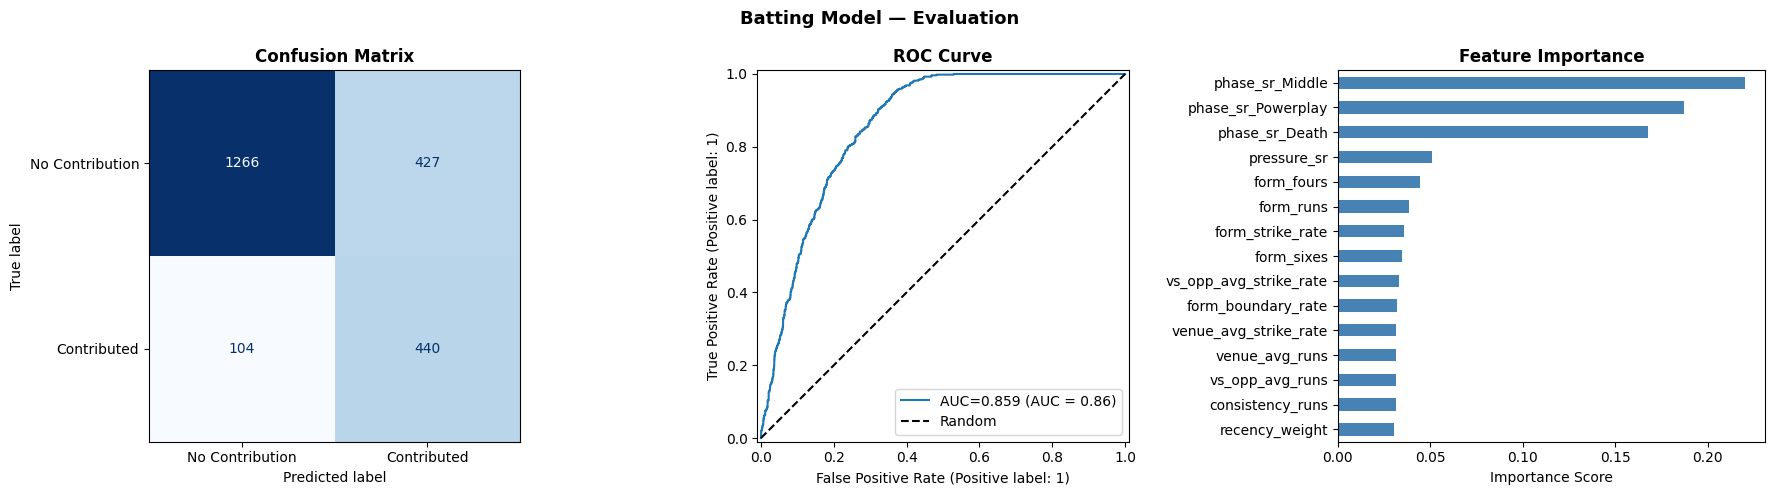

Plot saved.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Confusion Matrix ──────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['No Contribution', 'Contributed']).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title('Confusion Matrix', fontweight='bold')

# ── ROC Curve ─────────────────────────────────────────────────────
RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[1], name=f'AUC={roc_auc:.3f}')
axes[1].plot([0,1],[0,1],'k--', label='Random')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend()

# ── Feature Importance ────────────────────────────────────────────
imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=True)
imp.plot(kind='barh', ax=axes[2], color='steelblue')
axes[2].set_title('Feature Importance', fontweight='bold')
axes[2].set_xlabel('Importance Score')

plt.suptitle('Batting Model — Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PROCESSED_DIR + 'batting_model_evaluation.png', dpi=120)
plt.show()
print('Plot saved.')

## Step 7 — Predict Win Contribution Probability for Every Player

For each player, take their most recent feature snapshot and predict their probability of contributing to a win. This is the score that feeds the squad optimizer in Notebook 06.

In [ ]:
# Latest feature snapshot per player — most recent match's feature values
latest_batting = (
    batted
    .sort_values(['player', 'season', 'match_id'])
    .groupby('player')
    .last()
    .reset_index()
)

X_latest = latest_batting[FEATURES]
latest_batting['bat_win_prob'] = model.predict_proba(X_latest)[:, 1]

bat_scores = latest_batting[['player', 'bat_win_prob', 'season']].sort_values(
    'bat_win_prob', ascending=False
).reset_index(drop=True)

print('=== TOP 20 BATSMEN BY WIN CONTRIBUTION PROBABILITY ===')
print(bat_scores.head(20).to_string(index=False))

=== TOP 20 BATSMEN BY WIN CONTRIBUTION PROBABILITY ===
         player  bat_win_prob  season
    Dhruv Jurel      0.910908    2025
     JG Bethell      0.894976    2025
     UT Khawaja      0.885684    2016
     RR Rossouw      0.877654    2024
    Urvil Patel      0.851277    2025
B Sai Sudharsan      0.848861    2025
       D Brevis      0.847121    2025
 Vivrant Sharma      0.822975    2023
      JM Sharma      0.781590    2025
       AR Patel      0.774735    2025
      H Klaasen      0.771428    2025
   Sameer Rizvi      0.771291    2025
       WG Jacks      0.770888    2025
      MK Pandey      0.745671    2025
       MR Marsh      0.734319    2025
      JA Morkel      0.730733    2016
        TM Head      0.730043    2025
         JJ Roy      0.727936    2023
    NLTC Perera      0.724782    2016
     SO Hetmyer      0.715305    2025


## Step 8 — Save Model and Scores

In [ ]:
joblib.dump(model,    MODELS_DIR + 'batting_model.pkl')
joblib.dump(FEATURES, MODELS_DIR + 'batting_features.pkl')
bat_scores.to_parquet(PROCESSED_DIR + 'batting_scores.parquet', index=False)

print('Saved:')
print(f'  models/batting_model.pkl')
print(f'  models/batting_features.pkl')
print(f'  data/processed/batting_scores.parquet')

Saved:
  models/batting_model.pkl
  models/batting_features.pkl
  data/processed/batting_scores.parquet


## Step 9 — Validation Checks

In [ ]:
import os

checks = [
    ('batting_model.pkl saved',      os.path.exists(MODELS_DIR + 'batting_model.pkl')),
    ('batting_features.pkl saved',   os.path.exists(MODELS_DIR + 'batting_features.pkl')),
    ('batting_scores.parquet saved', os.path.exists(PROCESSED_DIR + 'batting_scores.parquet')),
    ('ROC-AUC above 0.55',           roc_auc > 0.55),
    ('Scores between 0 and 1',       bat_scores['bat_win_prob'].between(0, 1).all()),
    ('Scores has player column',      'player' in bat_scores.columns),
    ('More than 50 players scored',  len(bat_scores) > 50),
]

all_pass = True
for name, result in checks:
    icon = '✓' if result else '✗  FAIL'
    print(f'{icon}  {name}')
    if not result:
        all_pass = False

print(f'\n  Final ROC-AUC : {roc_auc:.4f}')
print()
if all_pass:
    print('All checks passed. Proceed to Notebook 05 — Bowling Model.')
else:
    print('Fix failing checks before proceeding.')

✓  batting_model.pkl saved
✓  batting_features.pkl saved
✓  batting_scores.parquet saved
✓  ROC-AUC above 0.55
✓  Scores between 0 and 1
✓  Scores has player column
✓  More than 50 players scored

  Final ROC-AUC : 0.8595

All checks passed. Proceed to Notebook 05 — Bowling Model.
